<a href="https://colab.research.google.com/github/manasamorthad/mini-project-2/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving new_data_urls.csv to new_data_urls.csv


In [2]:
import pandas as pd

df = pd.read_csv("new_data_urls.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nLabel distribution:")
print(df['status'].value_counts())
print("\nNull values:")
print(df.isnull().sum())

Shape: (822010, 2)

First 5 rows:
                                       url  status
0  0000111servicehelpdesk.godaddysites.com       0
1     000011accesswebform.godaddysites.com       0
2                             00003.online       0
3      0009servicedeskowa.godaddysites.com       0
4                     000n38p.wcomhost.com       0

Column names: ['url', 'status']

Label distribution:
status
1    427028
0    394982
Name: count, dtype: int64

Null values:
url       0
status    0
dtype: int64


In [3]:
import re

# Step 1: Remove duplicates
df = df.drop_duplicates(subset='url')

# Step 2: Lowercase
df['url'] = df['url'].str.lower().str.strip()

# Step 3: Extract domain from full URL
def extract_domain(url):
    url = str(url)
    url = re.sub(r'^https?://', '', url)   # remove http:// or https://
    url = re.sub(r'^www\.', '', url)       # remove www.
    url = url.split('/')[0]                # remove path after /
    url = url.split('?')[0]               # remove query params
    url = url.split(':')[0]               # remove port number
    return url.strip()

df['domain'] = df['url'].apply(extract_domain)

# Step 4: Remove too short or too long domains
df = df[df['domain'].str.len() >= 4]
df = df[df['domain'].str.len() <= 100]

# Step 5: Must contain a dot
df = df[df['domain'].str.contains(r'\.', regex=True)]

# Reset index
df = df.reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("\nLabel distribution after cleaning:")
print(df['status'].value_counts())
print("\nSample domains:")
print(df[['domain', 'status']].head(10))

Shape after cleaning: (804617, 3)

Label distribution after cleaning:
status
1    426960
0    377657
Name: count, dtype: int64

Sample domains:
                                    domain  status
0  0000111servicehelpdesk.godaddysites.com       0
1     000011accesswebform.godaddysites.com       0
2                             00003.online       0
3      0009servicedeskowa.godaddysites.com       0
4                     000n38p.wcomhost.com       0
5                     000n38t.wcomhost.com       0
6                     000n8pc.wcomhost.com       0
7                     000ne9r.wcomhost.com       0
8                     000njep.wcomhost.com       0
9                     000nku9.wcomhost.com       0


In [4]:
from sklearn.model_selection import train_test_split

X = df['domain']
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # same split every time you run
    stratify=y            # keeps same label ratio in both splits
)

print("Training size:  ", X_train.shape[0])
print("Testing size:   ", X_test.shape[0])
print("\nTrain label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())

Training size:   643693
Testing size:    160924

Train label distribution:
status
1    341568
0    302125
Name: count, dtype: int64

Test label distribution:
status
1    85392
0    75532
Name: count, dtype: int64


In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Step 1: Build tokenizer on training data ONLY
tokenizer = Tokenizer(char_level=True, filters='')
tokenizer.fit_on_texts(X_train)

print("Vocabulary size:", len(tokenizer.word_index))
print("Sample character mapping:", dict(list(tokenizer.word_index.items())[:10]))

# Step 2: Convert domains to number sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Step 3: Find the right max length (99th percentile)
lengths = [len(s) for s in X_train_seq]
max_len = int(np.percentile(lengths, 99))
print("\nRecommended max_len:", max_len)

# Step 4: Pad all sequences to same length
X_train_seq = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_seq  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

# Step 5: Convert labels to numpy arrays
y_train = y_train.values
y_test  = y_test.values

print("\nX_train shape:", X_train_seq.shape)
print("X_test shape: ", X_test_seq.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

Vocabulary size: 190
Sample character mapping: {'o': 1, '.': 2, 'c': 3, 'e': 4, 'a': 5, 'm': 6, 'i': 7, 's': 8, 'n': 9, 'r': 10}

Recommended max_len: 48

X_train shape: (643693, 48)
X_test shape:  (160924, 48)
y_train shape: (643693,)
y_test shape:  (160924,)


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Fix these values
vocab_size    = len(tokenizer.word_index) + 1  # 191
embedding_dim = 32
max_len       = X_train_seq.shape[1]           # 48

# Build model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training early if model stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,              # stop if no improvement for 2 epochs
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train_seq, y_train,
    validation_split=0.2,    # 20% of train used for validation
    epochs=10,               # max 10 epochs
    batch_size=256,          # process 256 samples at a time
    callbacks=[early_stop]
)

# Final test set evaluation
loss, accuracy = model.evaluate(X_test_seq, y_test, verbose=0)
print(f"\nTest Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/10
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - accuracy: 0.7755 - loss: 0.4622 - val_accuracy: 0.8060 - val_loss: 0.4089
Epoch 2/10
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - accuracy: 0.8206 - loss: 0.3843 - val_accuracy: 0.8303 - val_loss: 0.3693
Epoch 3/10
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.8373 - loss: 0.3507 - val_accuracy: 0.8454 - val_loss: 0.3350
Epoch 4/10
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8488 - loss: 0.3270 - val_accuracy: 0.8524 - val_loss: 0.3192
Epoch 5/10
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.8563 - loss: 0.3101 - val_accuracy: 0.8586 - val_loss: 0.3037
Epoch 6/10
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8616 - loss: 0.2962 - val_accuracy: 0.8648 - val_loss: 0.2960
Epoch 7/10
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.8667 - loss: 0.2845 - val_accuracy: 0.8571 - val_loss: 0.3047
Epoch 8/10
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.8708 -

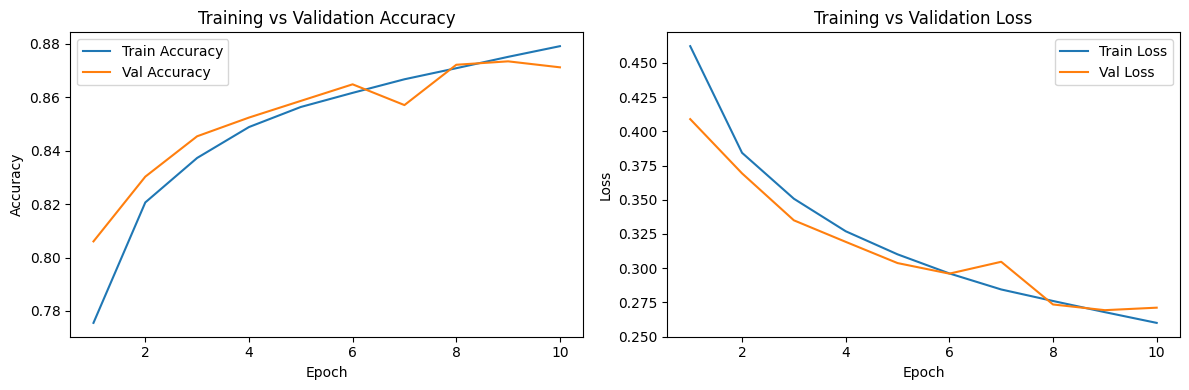

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'],     label='Train Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'],     label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

629/629 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step
Classification Report:
               precision    recall  f1-score   support

Malicious (0)       0.88      0.85      0.86     75532
   Benign (1)       0.87      0.90      0.88     85392

     accuracy                           0.88    160924
    macro avg       0.88      0.87      0.87    160924
 weighted avg       0.88      0.88      0.88    160924



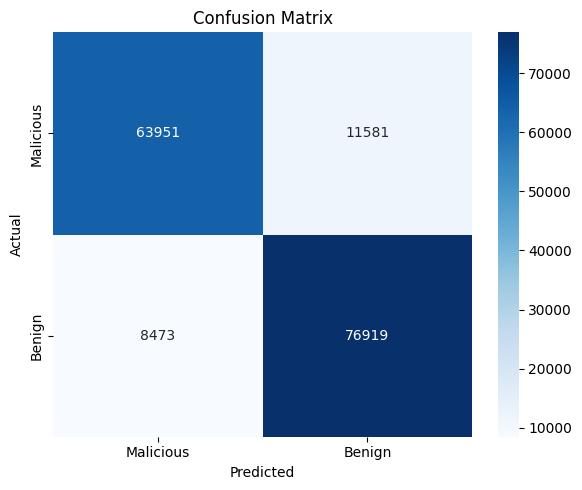

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_prob = model.predict(X_test_seq, batch_size=256, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Malicious (0)', 'Benign (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malicious', 'Benign'],
            yticklabels=['Malicious', 'Benign'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import f1_score, precision_score, recall_score

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("-" * 48)

best_f1 = 0
best_threshold = 0.5

for t in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    y_pred_t = (y_prob >= t).astype(int)
    p  = precision_score(y_test, y_pred_t, pos_label=0)
    r  = recall_score(y_test, y_pred_t, pos_label=0)
    f1 = f1_score(y_test, y_pred_t, pos_label=0)
    print(f"{t:<12} {p:<12.4f} {r:<12.4f} {f1:<12.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nBest threshold: {best_threshold}")
print(f"Best F1 score:  {best_f1:.4f}")

Threshold    Precision    Recall       F1 Score    
------------------------------------------------
0.3          0.9447       0.7577       0.8409      
0.35         0.9328       0.7801       0.8497      
0.4          0.9194       0.8020       0.8567      
0.45         0.9030       0.8235       0.8614      
0.5          0.8830       0.8467       0.8645      
0.55         0.8587       0.8730       0.8658      
0.6          0.8306       0.9011       0.8644      

Best threshold: 0.55
Best F1 score:  0.8658


In [11]:
import pickle

# Save model
model.save("lstm_dns_model.keras")
print("Model saved.")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved.")

# Save threshold and max_len
with open("config.txt", "w") as f:
    f.write(f"threshold=0.5\n")
    f.write(f"max_len={max_len}\n")
print("Config saved.")

# Save to Google Drive so you don't lose it
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy("lstm_dns_model.keras", "/content/drive/MyDrive/lstm_dns_model.keras")
shutil.copy("tokenizer.pkl",        "/content/drive/MyDrive/tokenizer.pkl")
shutil.copy("config.txt",           "/content/drive/MyDrive/config.txt")
print("\nAll files saved to Google Drive!")

Model saved.
Tokenizer saved.
Config saved.
Mounted at /content/drive

All files saved to Google Drive!


In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

THRESHOLD = 0.5
MAX_LEN   = max_len

def predict_domain(domain):
    # Clean the domain same way we cleaned training data
    import re
    domain = str(domain).lower().strip()
    domain = re.sub(r'^https?://', '', domain)
    domain = re.sub(r'^www\.', '', domain)
    domain = domain.split('/')[0]
    domain = domain.split('?')[0]
    domain = domain.split(':')[0]

    # Convert to sequence
    seq = tokenizer.texts_to_sequences([domain])
    seq = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict
    prob = float(model.predict(seq, verbose=0)[0][0])

    # prob close to 1 = benign, close to 0 = malicious
    if prob >= THRESHOLD:
        label = "BENIGN"
    else:
        label = "MALICIOUS"

    return label, round(prob, 4)

# Test with known domains
test_domains = [
    "google.com",
    "facebook.com",
    "github.com",
    "paypa1-secure-login.com",
    "xkzqjmnop.ru",
    "free-iphone-winner.xyz",
    "banking-secure-update.net",
    "stackoverflow.com",
    "go0gle-verify-account.com",
    "amazon.com"
]

print(f"{'Domain':<35} {'Label':<12} {'Probability'}")
print("-" * 60)
for domain in test_domains:
    label, prob = predict_domain(domain)
    print(f"{domain:<35} {label:<12} {prob}")

Domain                              Label        Probability
------------------------------------------------------------
google.com                          BENIGN       0.8496
facebook.com                        BENIGN       0.9982
github.com                          BENIGN       0.9102
paypa1-secure-login.com             MALICIOUS    0.0059
xkzqjmnop.ru                        MALICIOUS    0.003
free-iphone-winner.xyz              MALICIOUS    0.0028
banking-secure-update.net           MALICIOUS    0.0311
stackoverflow.com                   BENIGN       0.9847
go0gle-verify-account.com           MALICIOUS    0.0081
amazon.com                          BENIGN       0.999


   FINAL MODEL PERFORMANCE SUMMARY
  Dataset size     : 8,04,617 domains
  Training samples : 643,693
  Testing samples  : 160,924
  Vocabulary size  : 190
  Max domain length: 48
  Threshold used   : 0.5
----------------------------------------
  Accuracy         : 0.8754  (87.54%)
  Precision        : 0.8830  (88.30%)
  Recall           : 0.8467  (84.67%)
  F1 Score         : 0.8645  (86.45%)


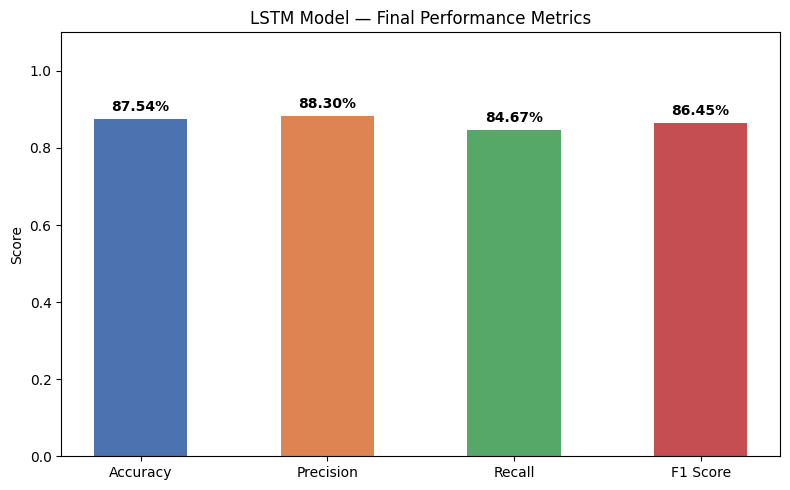

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Final metrics
y_pred_final = (y_prob >= THRESHOLD).astype(int)

accuracy  = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final, pos_label=0)
recall    = recall_score(y_test, y_pred_final, pos_label=0)
f1        = f1_score(y_test, y_pred_final, pos_label=0)

print("=" * 40)
print("   FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 40)
print(f"  Dataset size     : 8,04,617 domains")
print(f"  Training samples : {len(X_train_seq):,}")
print(f"  Testing samples  : {len(X_test_seq):,}")
print(f"  Vocabulary size  : {len(tokenizer.word_index)}")
print(f"  Max domain length: {MAX_LEN}")
print(f"  Threshold used   : {THRESHOLD}")
print("-" * 40)
print(f"  Accuracy         : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision        : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall           : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1 Score         : {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 40)

# Bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [accuracy, precision, recall, f1]
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=colors, width=0.5)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('LSTM Model — Final Performance Metrics')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val*100:.2f}%',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Blacklist module

In [14]:
import pandas as pd
import requests
import re

# Download live blacklist from URLhaus (abuse.ch)
print("Downloading blacklist from URLhaus...")
url = "https://urlhaus.abuse.ch/downloads/csv_recent/"
response = requests.get(url)

# Save raw file
with open("urlhaus_blacklist.txt", "wb") as f:
    f.write(response.content)

# Parse it — skip comment lines starting with #
lines = response.content.decode('utf-8').splitlines()
domains = set()

for line in lines:
    if line.startswith('#') or line.strip() == '':
        continue
    parts = line.split(',')
    if len(parts) >= 3:
        raw_url = parts[2].strip().strip('"')
        # Extract domain from URL
        raw_url = re.sub(r'^https?://', '', raw_url)
        raw_url = re.sub(r'^www\.', '', raw_url)
        domain  = raw_url.split('/')[0].split('?')[0].split(':')[0].lower()
        if '.' in domain and len(domain) > 4:
            domains.add(domain)

blacklist = domains
print(f"Total malicious domains in blacklist: {len(blacklist)}")
print("\nSample blacklisted domains:")
for d in list(blacklist)[:10]:
    print(" ", d)

Total malicious domains in blacklist: 10222

Sample blacklisted domains:
  opticwin.jokerun.in.net
  zkgvelgx.amber-drift.in.net
  dist-k4-meta.fluxovivavo.in.net
  59.110.40.60
  125.44.211.113
  big-city.solenta.in.net
  61.137.153.168
  tri-forgeix.momentumharbor.in.net
  pzwvu.aurorift.in.net
  pub-c62500800d9244beabd2934a10b4770b.r2.dev


In [15]:
def hybrid_predict(domain):
    # Clean domain
    domain = str(domain).lower().strip()
    domain = re.sub(r'^https?://', '', domain)
    domain = re.sub(r'^www\.', '', domain)
    domain = domain.split('/')[0]
    domain = domain.split('?')[0]
    domain = domain.split(':')[0]

    # Step 1: Check blacklist first (instant decision)
    if domain in blacklist:
        return {
            "domain"     : domain,
            "label"      : "MALICIOUS",
            "source"     : "Blacklist",
            "probability": 0.0
        }

    # Step 2: Use LSTM model for unknown domains
    seq  = tokenizer.texts_to_sequences([domain])
    seq  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = float(model.predict(seq, verbose=0)[0][0])

    label = "BENIGN" if prob >= THRESHOLD else "MALICIOUS"

    return {
        "domain"     : domain,
        "label"      : label,
        "source"     : "LSTM Model",
        "probability": round(prob, 4)
    }

# Test with mix of domains
test_domains = [
    "google.com",
    "github.com",
    "amazon.com",
    "paypa1-secure-login.com",
    "xkzqjmnop.ru",
    "free-iphone-winner.xyz",
    "go0gle-verify-account.com",
    "stackoverflow.com",
] + list(blacklist)[:3]   # add 3 real blacklisted domains

print(f"{'Domain':<45} {'Label':<12} {'Source':<15} {'Probability'}")
print("-" * 85)
for domain in test_domains:
    result = hybrid_predict(domain)
    print(f"{result['domain']:<45} {result['label']:<12} {result['source']:<15} {result['probability']}")

Domain                                        Label        Source          Probability
-------------------------------------------------------------------------------------
google.com                                    BENIGN       LSTM Model      0.8496
github.com                                    MALICIOUS    Blacklist       0.0
amazon.com                                    BENIGN       LSTM Model      0.999
paypa1-secure-login.com                       MALICIOUS    LSTM Model      0.0059
xkzqjmnop.ru                                  MALICIOUS    LSTM Model      0.003
free-iphone-winner.xyz                        MALICIOUS    LSTM Model      0.0028
go0gle-verify-account.com                     MALICIOUS    LSTM Model      0.0081
stackoverflow.com                             BENIGN       LSTM Model      0.9847
opticwin.jokerun.in.net                       MALICIOUS    Blacklist       0.0
zkgvelgx.amber-drift.in.net                   MALICIOUS    Blacklist       0.0
dist-k4-meta.fluxo

In [16]:
# Trusted domains that should NEVER be flagged as malicious
whitelist = set([
    "google.com", "github.com", "amazon.com", "microsoft.com",
    "apple.com", "facebook.com", "twitter.com", "linkedin.com",
    "youtube.com", "wikipedia.org", "stackoverflow.com",
    "reddit.com", "instagram.com", "whatsapp.com", "netflix.com",
    "dropbox.com", "adobe.com", "cloudflare.com", "yahoo.com",
    "bing.com", "live.com", "office.com", "windows.com",
    "python.org", "tensorflow.org", "kaggle.com", "colab.research.google.com"
])

def hybrid_predict(domain):
    import re

    # Clean domain
    domain = str(domain).lower().strip()
    domain = re.sub(r'^https?://', '', domain)
    domain = re.sub(r'^www\.', '', domain)
    domain = domain.split('/')[0]
    domain = domain.split('?')[0]
    domain = domain.split(':')[0]

    # Step 1: Check whitelist first — always benign
    if domain in whitelist:
        return {
            "domain"     : domain,
            "label"      : "BENIGN",
            "source"     : "Whitelist",
            "probability": 1.0
        }

    # Step 2: Check blacklist — instantly malicious
    if domain in blacklist:
        return {
            "domain"     : domain,
            "label"      : "MALICIOUS",
            "source"     : "Blacklist",
            "probability": 0.0
        }

    # Step 3: Use LSTM for unknown domains
    seq  = tokenizer.texts_to_sequences([domain])
    seq  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = float(model.predict(seq, verbose=0)[0][0])

    label = "BENIGN" if prob >= THRESHOLD else "MALICIOUS"

    return {
        "domain"     : domain,
        "label"      : label,
        "source"     : "LSTM Model",
        "probability": round(prob, 4)
    }

# Test again
test_domains = [
    "google.com",
    "github.com",
    "amazon.com",
    "paypa1-secure-login.com",
    "xkzqjmnop.ru",
    "free-iphone-winner.xyz",
    "go0gle-verify-account.com",
    "stackoverflow.com",
] + list(blacklist)[:3]

print(f"{'Domain':<45} {'Label':<12} {'Source':<15} {'Probability'}")
print("-" * 85)
for domain in test_domains:
    result = hybrid_predict(domain)
    print(f"{result['domain']:<45} {result['label']:<12} {result['source']:<15} {result['probability']}")

Domain                                        Label        Source          Probability
-------------------------------------------------------------------------------------
google.com                                    BENIGN       Whitelist       1.0
github.com                                    BENIGN       Whitelist       1.0
amazon.com                                    BENIGN       Whitelist       1.0
paypa1-secure-login.com                       MALICIOUS    LSTM Model      0.0059
xkzqjmnop.ru                                  MALICIOUS    LSTM Model      0.003
free-iphone-winner.xyz                        MALICIOUS    LSTM Model      0.0028
go0gle-verify-account.com                     MALICIOUS    LSTM Model      0.0081
stackoverflow.com                             BENIGN       Whitelist       1.0
opticwin.jokerun.in.net                       MALICIOUS    Blacklist       0.0
zkgvelgx.amber-drift.in.net                   MALICIOUS    Blacklist       0.0
dist-k4-meta.fluxovivavo.i

In [17]:
import random
import datetime

# Sinkhole IP — non-routable address, blocks the connection
SINKHOLE_IP = "0.0.0.0"

# Honeypot IP — fake controlled server for monitoring attackers
HONEYPOT_IP = "192.168.1.100"

# Log storage
detection_log = []

def handle_domain(domain):
    result = hybrid_predict(domain)

    entry = {
        "timestamp"  : datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "domain"     : result['domain'],
        "label"      : result['label'],
        "source"     : result['source'],
        "probability": result['probability'],
        "action"     : None,
        "redirect_ip": None
    }

    if result['label'] == "MALICIOUS":
        # 20% chance → honeypot (to collect attacker info)
        # 80% chance → sinkhole (to block)
        if random.random() < 0.2:
            entry['action']      = "Honeypot"
            entry['redirect_ip'] = HONEYPOT_IP
        else:
            entry['action']      = "Sinkhole"
            entry['redirect_ip'] = SINKHOLE_IP
    else:
        entry['action']      = "Allow"
        entry['redirect_ip'] = "Pass-through"

    detection_log.append(entry)
    return entry

# Simulate processing a batch of domains
simulate_domains = [
    "google.com",
    "github.com",
    "paypa1-secure-login.com",
    "xkzqjmnop.ru",
    "free-iphone-winner.xyz",
    "amazon.com",
    "go0gle-verify-account.com",
    "stackoverflow.com",
    "opticwin.jokerun.in.net",
    "netflix.com",
    "banking-secure-update.net",
    "facebook.com"
]

print(f"{'Timestamp':<22} {'Domain':<35} {'Label':<12} {'Action':<12} {'Redirect IP'}")
print("-" * 100)
for domain in simulate_domains:
    entry = handle_domain(domain)
    print(f"{entry['timestamp']:<22} {entry['domain']:<35} {entry['label']:<12} {entry['action']:<12} {entry['redirect_ip']}")

print(f"\nTotal domains processed : {len(detection_log)}")
print(f"Malicious detected      : {sum(1 for e in detection_log if e['label'] == 'MALICIOUS')}")
print(f"Benign allowed          : {sum(1 for e in detection_log if e['label'] == 'BENIGN')}")
print(f"Sinkholed               : {sum(1 for e in detection_log if e['action'] == 'Sinkhole')}")
print(f"Sent to honeypot        : {sum(1 for e in detection_log if e['action'] == 'Honeypot')}")

Timestamp              Domain                              Label        Action       Redirect IP
----------------------------------------------------------------------------------------------------
2026-03-28 18:01:36    google.com                          BENIGN       Allow        Pass-through
2026-03-28 18:01:36    github.com                          BENIGN       Allow        Pass-through
2026-03-28 18:01:36    paypa1-secure-login.com             MALICIOUS    Honeypot     192.168.1.100
2026-03-28 18:01:36    xkzqjmnop.ru                        MALICIOUS    Sinkhole     0.0.0.0
2026-03-28 18:01:36    free-iphone-winner.xyz              MALICIOUS    Sinkhole     0.0.0.0
2026-03-28 18:01:36    amazon.com                          BENIGN       Allow        Pass-through
2026-03-28 18:01:36    go0gle-verify-account.com           MALICIOUS    Sinkhole     0.0.0.0
2026-03-28 18:01:36    stackoverflow.com                   BENIGN       Allow        Pass-through
2026-03-28 18:01:36    opticwin.

In [18]:
import pandas as pd

# Convert log to dataframe and save
log_df = pd.DataFrame(detection_log)
log_df.to_csv("detection_log.csv", index=False)

print("Detection log saved!")
print(f"\nLog preview:")
print(log_df[['timestamp', 'domain', 'label', 'action', 'redirect_ip']])

# Also save blacklist and whitelist for later use
import pickle

with open("blacklist.pkl", "wb") as f:
    pickle.dump(blacklist, f)

with open("whitelist.pkl", "wb") as f:
    pickle.dump(whitelist, f)

print("\nBlacklist and whitelist saved!")

# Copy everything to Google Drive
import shutil
shutil.copy("detection_log.csv", "/content/drive/MyDrive/detection_log.csv")
shutil.copy("blacklist.pkl",     "/content/drive/MyDrive/blacklist.pkl")
shutil.copy("whitelist.pkl",     "/content/drive/MyDrive/whitelist.pkl")

print("All files backed up to Google Drive!")

Detection log saved!

Log preview:
              timestamp                     domain      label    action  \
0   2026-03-28 18:01:36                 google.com     BENIGN     Allow   
1   2026-03-28 18:01:36                 github.com     BENIGN     Allow   
2   2026-03-28 18:01:36    paypa1-secure-login.com  MALICIOUS  Honeypot   
3   2026-03-28 18:01:36               xkzqjmnop.ru  MALICIOUS  Sinkhole   
4   2026-03-28 18:01:36     free-iphone-winner.xyz  MALICIOUS  Sinkhole   
5   2026-03-28 18:01:36                 amazon.com     BENIGN     Allow   
6   2026-03-28 18:01:36  go0gle-verify-account.com  MALICIOUS  Sinkhole   
7   2026-03-28 18:01:36          stackoverflow.com     BENIGN     Allow   
8   2026-03-28 18:01:36    opticwin.jokerun.in.net  MALICIOUS  Sinkhole   
9   2026-03-28 18:01:36                netflix.com     BENIGN     Allow   
10  2026-03-28 18:01:36  banking-secure-update.net  MALICIOUS  Sinkhole   
11  2026-03-28 18:01:36               facebook.com     BENIGN    

In [19]:
from google.colab import files
uploaded=files.upload()

Saving dns_traffic.pcap to dns_traffic.pcap


In [20]:
!pip install scapy -q

from scapy.all import rdpcap
from scapy.layers.dns import DNS, DNSQR
import pandas as pd

# Load your real PCAP file
packets = rdpcap("dns_traffic.pcap")
print(f"Total packets loaded: {len(packets)}")

# Extract DNS queries only
dns_queries = []

for pkt in packets:
    try:
        # Check if packet has DNS layer and is a query (not response)
        if pkt.haslayer(DNS) and pkt[DNS].qr == 0:  # qr=0 means query
            if pkt.haslayer(DNSQR):
                domain = pkt[DNSQR].qname.decode().rstrip('.')
                domain = domain.lower().strip()

                # Skip empty or too short
                if len(domain) < 4:
                    continue

                dns_queries.append({
                    "domain": domain,
                    "src_ip": pkt['IP'].src if pkt.haslayer('IP') else "unknown",
                    "dst_ip": pkt['IP'].dst if pkt.haslayer('IP') else "unknown",
                })
    except Exception:
        continue

# Convert to DataFrame
pcap_df = pd.DataFrame(dns_queries)
pcap_df = pcap_df.drop_duplicates(subset='domain')
pcap_df = pcap_df.reset_index(drop=True)

print(f"Unique DNS queries found: {len(pcap_df)}")
print("\nSample domains extracted:")
print(pcap_df['domain'].head(20).tolist())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 40.4 MB/s eta 0:00:00
Total packets loaded: 399
Unique DNS queries found: 156

Sample domains extracted:
['colab.research.google.com', 'lh3.google.com', 'ogads-pa.clients6.google.com', 'lh3.googleusercontent.com', 'play.google.com', 'optimizationguide-pa.googleapis.com', 'amazon.in', 'safebrowsing.google.com', 'www.amazon.in', 'unagi.amazon.in', 'm.media-amazon.com', 'images-eu.ssl-images-amazon.com', 'images-na.ssl-images-amazon.com', 'content-autofill.googleapis.com', 'data.amazon.in', 'p47r3qkl5raepa5flsczs7khqq.appsync-api.eu-west-1.amazonaws.com', 'p47r3qkl5raepa5flsczs7khqq.appsync-realtime-api.eu-west-1.amazonaws.com', 'metrics.media-amazon.com', 'd231gvmk20yd16.cloudfront.net', 'unagi-eu.amazon.com']


In [21]:
import pandas as pd

print("Running hybrid detection on real DNS traffic...")
print("-" * 70)

results = []
for domain in pcap_df['domain']:
    result = handle_domain(domain)
    results.append(result)

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Show summary
total     = len(results_df)
malicious = len(results_df[results_df['label'] == 'MALICIOUS'])
benign    = len(results_df[results_df['label'] == 'BENIGN'])
blacklist_hits = len(results_df[results_df['source'] == 'Blacklist'])
whitelist_hits = len(results_df[results_df['source'] == 'Whitelist'])
lstm_hits      = len(results_df[results_df['source'] == 'LSTM Model'])

print(f"\nTotal domains analysed : {total}")
print(f"Malicious detected     : {malicious}")
print(f"Benign allowed         : {benign}")
print(f"Blacklist hits         : {blacklist_hits}")
print(f"Whitelist hits         : {whitelist_hits}")
print(f"LSTM decisions         : {lstm_hits}")

print("\nMalicious domains found in your traffic:")
print("-" * 70)
mal_df = results_df[results_df['label'] == 'MALICIOUS']
if len(mal_df) == 0:
    print("No malicious domains detected — your traffic is clean!")
else:
    for _, row in mal_df.iterrows():
        print(f"  {row['domain']:<45} Source: {row['source']}")

print("\nFull results saved to pcap_detection_results.csv")
results_df.to_csv("pcap_detection_results.csv", index=False)

Running hybrid detection on real DNS traffic...
----------------------------------------------------------------------

Total domains analysed : 156
Malicious detected     : 94
Benign allowed         : 62
Blacklist hits         : 0
Whitelist hits         : 10
LSTM decisions         : 146

Malicious domains found in your traffic:
----------------------------------------------------------------------
  ogads-pa.clients6.google.com                  Source: LSTM Model
  optimizationguide-pa.googleapis.com           Source: LSTM Model
  amazon.in                                     Source: LSTM Model
  safebrowsing.google.com                       Source: LSTM Model
  amazon.in                                     Source: LSTM Model
  unagi.amazon.in                               Source: LSTM Model
  m.media-amazon.com                            Source: LSTM Model
  images-eu.ssl-images-amazon.com               Source: LSTM Model
  images-na.ssl-images-amazon.com               Source: LSTM M

In [22]:
import tldextract

# Install tldextract
!pip install tldextract -q

def get_root_domain(domain):
    extracted = tldextract.extract(domain)
    # Returns root domain only e.g. amazon.in, google.com
    if extracted.domain and extracted.suffix:
        return f"{extracted.domain}.{extracted.suffix}"
    return domain

# Extended whitelist with common legitimate domains
extended_whitelist = whitelist | set([
    "google.com", "google.co.in", "googleapis.com", "googleusercontent.com",
    "gstatic.com", "googlevideo.com", "googletagmanager.com", "googlesyndication.com",
    "doubleclick.net", "gvt2.com", "ggpht.com", "ytimg.com",
    "amazon.com", "amazon.in", "amazonaws.com", "amazon-adsystem.com",
    "cloudfront.net", "nflxext.com", "nflxso.net", "nflximg.net", "netflix.com",
    "licdn.com", "linkedin.com", "instagram.com", "cdninstagram.com",
    "github.com", "githubassets.com",
    "youtube.com", "youtu.be",
    "microsoft.com", "msn.com", "akamaized.net",
    "baidu.com", "leetcode.com",
    "sentry.io", "clarity.ms", "onetrust.io",
    "live-video.net", "twitch.tv",
    "opera-api.com"
])

def hybrid_predict_v2(domain):
    import re

    # Clean
    original = domain
    domain = str(domain).lower().strip()
    domain = re.sub(r'^https?://', '', domain)
    domain = re.sub(r'^www\.', '', domain)
    domain = domain.split('/')[0].split('?')[0].split(':')[0]

    # Get root domain for whitelist/blacklist checking
    root = get_root_domain(domain)

    # Step 1: Check whitelist (root domain)
    if root in extended_whitelist or domain in extended_whitelist:
        return {
            "domain": original, "root": root,
            "label": "BENIGN", "source": "Whitelist", "probability": 1.0
        }

    # Step 2: Check blacklist (root domain)
    if root in blacklist or domain in blacklist:
        return {
            "domain": original, "root": root,
            "label": "MALICIOUS", "source": "Blacklist", "probability": 0.0
        }

    # Step 3: LSTM on root domain (more reliable than full subdomain)
    seq  = tokenizer.texts_to_sequences([root])
    seq  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = float(model.predict(seq, verbose=0)[0][0])
    label = "BENIGN" if prob >= THRESHOLD else "MALICIOUS"

    return {
        "domain": original, "root": root,
        "label": label, "source": "LSTM Model", "probability": round(prob, 4)
    }

# Re-run on PCAP domains
print("Re-running detection with improved hybrid detector...")
results_v2 = []
for domain in pcap_df['domain']:
    result = hybrid_predict_v2(domain)
    results_v2.append(result)

results_v2_df = pd.DataFrame(results_v2)

# Summary
total     = len(results_v2_df)
malicious = len(results_v2_df[results_v2_df['label'] == 'MALICIOUS'])
benign    = len(results_v2_df[results_v2_df['label'] == 'BENIGN'])

print(f"\nTotal domains analysed : {total}")
print(f"Malicious detected     : {malicious}")
print(f"Benign allowed         : {benign}")

print("\nMalicious domains found:")
print("-" * 70)
mal_df = results_v2_df[results_v2_df['label'] == 'MALICIOUS']
if len(mal_df) == 0:
    print("No malicious domains — your traffic is clean!")
else:
    for _, row in mal_df.iterrows():
        print(f"  {row['domain']:<50} Root: {row['root']}")

results_v2_df.to_csv("pcap_detection_results_v2.csv", index=False)
print("\nSaved to pcap_detection_results_v2.csv")

ModuleNotFoundError: No module named 'tldextract'